# 1 Data loading and processing

## 1.1 Environment preparation and data loading [Code needs to be added]

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler,MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error
import math
import warnings
warnings.filterwarnings('ignore')


data_path = '../data/'

# Load 5 core datasets [Code needs to be filled in]
telemetry = pd.read_csv(os.path.join(data_path, 'PdM_telemetry.csv'), parse_dates=['datetime'])  # telemetry data
errors = pd.read_csv(os.path.join(data_path, 'PdM_errors.csv'), parse_dates=['datetime'])      # errors data
maint = pd.read_csv(os.path.join(data_path, 'PdM_maint.csv'), parse_dates=['datetime'])       # maintain data
failures = pd.read_csv(os.path.join(data_path, 'PdM_failures.csv'), parse_dates=['datetime'])    # failures data
machines = pd.read_csv(os.path.join(data_path, 'PdM_machines.csv'))                              # machine metadata


# View basic information for each dataset
datasets = {
    'telemetry data(PdM_telemetry.csv)': telemetry,
    'errors data(PdM_errors.csv)': errors,
    'maintain data(PdM_maint.csv)': maint,
    'failures data(PdM_failures.csv)': failures,
    'machine metadata(PdM_machines.csv)': machines
}

for name, df in datasets.items():
    print(f"\n=== {name} ===")
    print(f"Data volume: {len(df)} Rows × {len(df.columns)} Columns")
    print(f"Field name: {df.columns.tolist()}")
    missing_ratio = df.isnull().sum() / len(df) * 100
    print("Proportion of missing values:")
    for col, ratio in missing_ratio.items():
        print(f"  {col}: {ratio:.2f}%")
    print(f"First two rows of data: \n{df.head(2)}")


FileNotFoundError: [Errno 2] No such file or directory: '../data/PdM_telemetry.csv'

## 1.2 View the time range in which the data was generated, as well as the number and distribution of devices.

In [ ]:
# Standardize the time field (unify it to datetime format, hour level).
def standardize_datetime(df, col='datetime'):
    df[col] = pd.to_datetime(df[col])
    df[col] = df[col].dt.floor('H')
    return df

# Standardize all datasets containing datetime fields
for df in [telemetry, errors, maint, failures]:
    df = standardize_datetime(df)


# View the standardized data time range
print("\nTelemetry data time range:", telemetry['datetime'].min(), " to ", telemetry['datetime'].max())
print("failures data time range:", failures['datetime'].min(), " to ", failures['datetime'].max())
print("Number of devices:", machines['machineID'].nunique())
print("Equipment model distribution:", machines['model'].value_counts().to_dict())


Telemetry data time range: 2015-01-01 06:00:00  to  2016-01-01 06:00:00
failures data time range: 2015-01-02 03:00:00  to  2015-12-31 06:00:00
Number of devices: 100
Equipment model distribution: {'model3': 35, 'model4': 32, 'model2': 17, 'model1': 16}


## 1.3	View the failure count for each component of each device, presented in a cumulative bar chart. [Code needed]

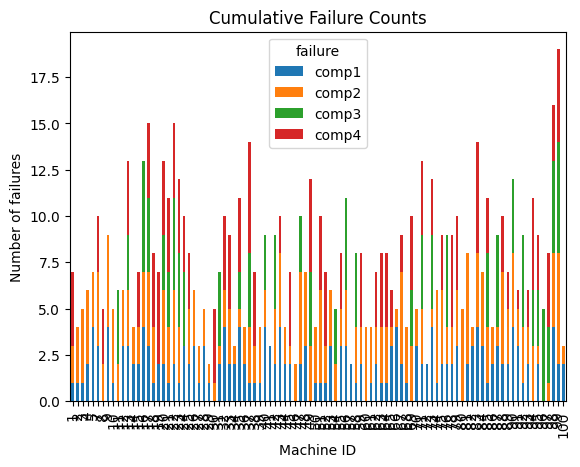

In [ ]:
failure_cnt = failures.groupby(["machineID", "failure"]).size().reset_index()
failure_cnt.columns = ["machineID", "failure","failure_cnt"]

#count the number of failures for each component on the device, and show the cumulative totals using bar chats
#collect statistics for different sensors and generate correlation heatmaps. A score above0.5 indicates strong correlation
failure_cnt = failures.groupby(["machineID", "failure"]).size().reset_index()
failure_cnt.columns = ["machineID", "failure","failure_cnt"]


#Generate a diagram that indicates the correlation between error events and failure events

failure_cnt.pivot(index='machineID', columns='failure', values='failure_cnt').fillna(0).plot(kind='bar', stacked=True)
plt.xlabel("Machine ID")
plt.ylabel("Number of failures")
plt.title("Cumulative Failure Counts")
plt.show()

### 1.4 Sensor Correlation Heatmap [Code needed]

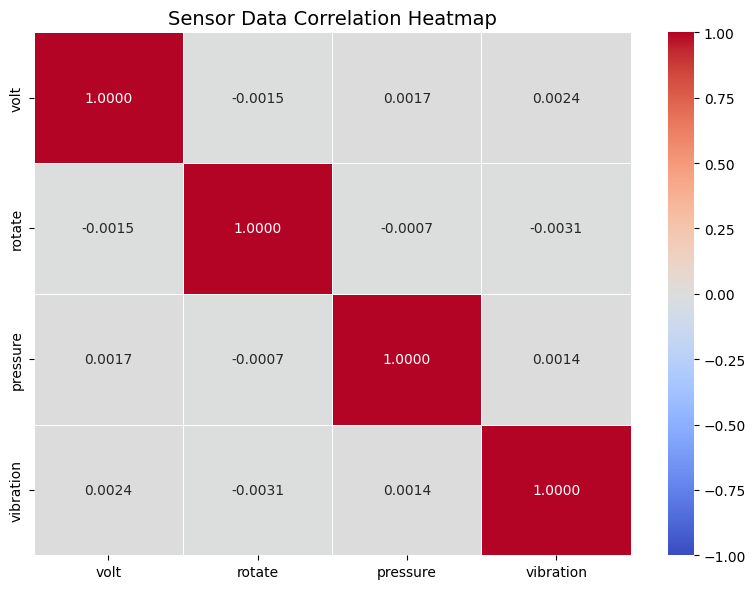


Sensor correlation analysis:
volt and rotate are weakly correlated (correlation coefficient: -0.0015)
volt and pressure are weakly correlated (correlation coefficient: 0.0017)
volt and vibration are weakly correlated (correlation coefficient: 0.0024)
rotate and pressure are weakly correlated (correlation coefficient: -0.0007)
rotate and vibration are weakly correlated (correlation coefficient: -0.0031)
pressure and vibration are weakly correlated (correlation coefficient: 0.0014)


In [ ]:
# Select four sensor fields from the telemetry data and calculate the correlation coefficient between these sensor fields.
sensor_cols = ['volt', 'rotate', 'pressure', 'vibration']
sensor_corr = telemetry[sensor_cols].corr()

# Drawing a heat map
plt.figure(figsize=(8, 6))
sns.heatmap(sensor_corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt='.4f', linewidths=0.5)
plt.title('Sensor Data Correlation Heatmap', fontsize=14)
plt.tight_layout()
plt.show()


print("\nSensor correlation analysis:")
for i in range(len(sensor_cols)):
    for j in range(i+1, len(sensor_cols)):
        corr_val = sensor_corr.iloc[i, j]
        if abs(corr_val) > 0.5:
            print(f"Strong correlation between {sensor_cols[i]} and {sensor_cols[j]} (correlation coefficient: {corr_val:.4f})")
        elif abs(corr_val) < 0.1:
            print(f"{sensor_cols[i]} and {sensor_cols[j]} are weakly correlated (correlation coefficient: {corr_val:.4f})")

## 1.5 Correlation analysis between error and failure events [Code needed]

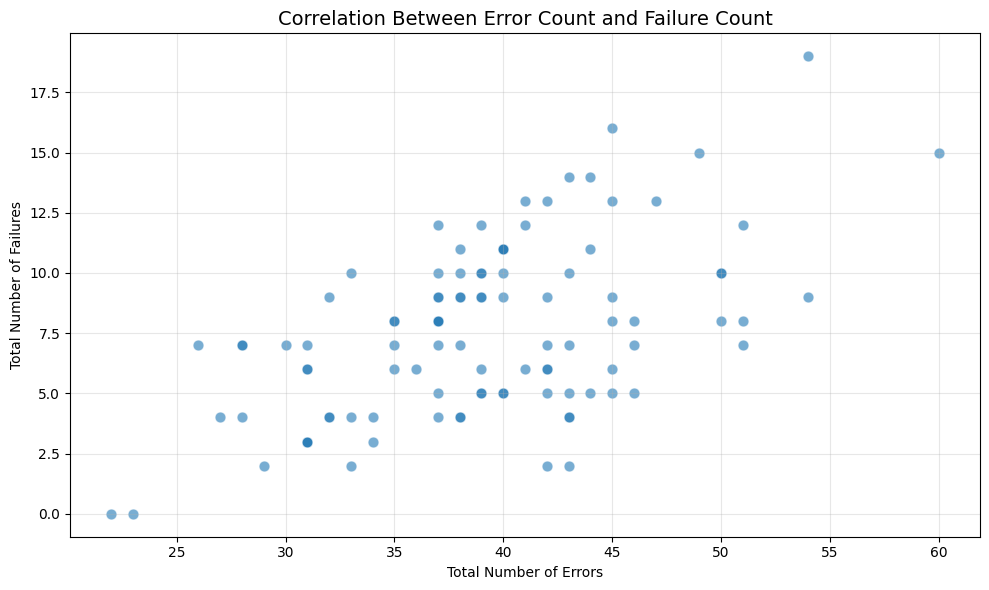

Correlation coefficient between the number of errors and the number of failures: 0.54


In [ ]:
# Count the number of errors that occur for each device
error_machine_counts = errors.groupby('machineID')['errorID'].count().reset_index()
error_machine_counts.columns = ['machineID', 'error_count']

# Count the number of failures for each device
failure_machine_counts = failures.groupby('machineID')['failure'].count().reset_index()
failure_machine_counts.columns = ['machineID', 'failure_count']

# Merge error and failure statistics, and fill null values with 0.
error_failure_merge = error_machine_counts.merge(failure_machine_counts, on='machineID', how='outer').fillna(0)

# Plot a scatter plot (number of errors vs. number of failures).
plt.figure(figsize=(10, 6))
sns.scatterplot(x='error_count', y='failure_count', data=error_failure_merge, alpha=0.6, s=60)
plt.title('Correlation Between Error Count and Failure Count', fontsize=14)
plt.xlabel('Total Number of Errors', fontsize=10)
plt.ylabel('Total Number of Failures', fontsize=10)
plt.grid(alpha=0.3)

# Calculate correlation coefficient
corr = error_failure_merge['error_count'].corr(error_failure_merge['failure_count'])

plt.tight_layout()
plt.show()

print(f"Correlation coefficient between the number of errors and the number of failures: {corr:.2f}")

# 2 Feature Engineering

## 2.1 Merge the failure and main events [Code needed]

In [ ]:
def merge_failures_maint(failures_df, maint_df):

    # Merge the failure table and the maintenance table, treating them as a new failure event.
    # Select the desired columns and add event types.
    failures_sel = failures_df[['machineID', 'datetime']].copy()
    maint_sel = maint_df[['machineID', 'datetime']].copy()
    failures_sel['event_type'] = 'failure'    #code needed
    maint_sel['event_type'] = 'maintenance'   #code needed

    # Merge and deduplicate (the same device may have both a failure and maintenance issues at the same time; retain only one of them).
    merged_events = pd.concat([failures_sel, maint_sel]).drop_duplicates(['machineID', 'datetime'])
    merged_events = merged_events.sort_values(by=['machineID', 'datetime']).reset_index(drop=True)
    return merged_events

print("=== Merge failure and maintain events ===")
merged_events = merge_failures_maint(failures, maint)
print(f"Total number of failure events after merger: {len(merged_events)}")
print(f"Event type distribution:\n{merged_events['event_type'].value_counts()}")

=== Merge failure and maintain events ===
Total number of failure events after merger: 2545
Event type distribution:
maintenance    1826
failure         719
Name: event_type, dtype: int64


## 2.2 Create a Remaining Life (RUL) tag [Code needed]

In [ ]:
# Generate RUL tags
def create_rul_labels(telemetry_df, merged_events_df):
    """
    Generate RUL tags (unit: hours) based on merged failure events (fialure + maintenance).
    Core Logic:
        1. Calculate the maximum lifespan of a single device:

            a. With failure events → Maximum time difference between adjacent failure events

            b. No failure events → Total runtime of telemetry data

        2. With subsequent failure events → RUL = Hourly difference to the next failure event

        3. No subsequent failure events → RUL = Maximum device lifespan - Hourly difference from the last failure event

        4. Force all RUL values ≥ 0
    """

    telemetry_df = telemetry_df.sort_values(by=['machineID', 'datetime']).reset_index(drop=True)
    merged_events_df = merged_events_df.sort_values(by=['machineID', 'datetime']).reset_index(drop=True)

    all_rul = []
    machine_max_life = {}  # Store the maximum lifespan of each device.

    for machine_id in telemetry_df['machineID'].unique():
        machine_telemetry = telemetry_df[telemetry_df['machineID'] == machine_id].copy().reset_index(drop=True)
        machine_events = merged_events_df[merged_events_df['machineID'] == machine_id].copy().reset_index(drop=True)

        telemetry_times = machine_telemetry['datetime'].values
        event_times = machine_events['datetime'].values
        machine_rul = []

        # ========== Step 1: Calculate the maximum lifespan of the device (based on failure events). ==========
        if len(event_times) >= 2:
            # If there are two or more failure events, calculate the time difference (in hours)
            #  between adjacent events and take the maximum value.
            event_intervals = []
            for i in range(1, len(event_times)):
                interval_hours = (event_times[i] - event_times[i-1]).astype('timedelta64[h]').astype(int)
                event_intervals.append(interval_hours)
            max_life_hours = max(event_intervals)

        elif len(event_times) == 1:
            # Only one failure event → Take the maximum runtime before and after the failure.
            tele_start = telemetry_times[0]
            tele_end = telemetry_times[-1]
            pre_event_hours = (event_times[0] - tele_start).astype('timedelta64[h]').astype(int)
            post_event_hours = (tele_end - event_times[0]).astype('timedelta64[h]').astype(int)
            max_life_hours = max(pre_event_hours, post_event_hours)

        else:
            # No failure events → Maximum lifetime = Total telemetry runtime
            tele_start = telemetry_times[0]
            tele_end = telemetry_times[-1]
            max_life_hours = (tele_end - tele_start).astype('timedelta64[h]').astype(int)

        machine_max_life[machine_id] = max_life_hours

        print(f"Device {machine_id} | Maximum Service Life (Based on Failure & Maintenance): {max_life_hours} hours")

        # ========== Step 2: Calculate the RUL for each record ==========

        if len(event_times) > 0:
            # There are existing failure events
            indices = np.searchsorted(event_times, telemetry_times, side='right')
            for i, idx in enumerate(indices):
                if idx < len(event_times):
                    # There is a subsequent failure event → RUL = hour difference until the next event
                    time_diff = (telemetry_times[i] - event_times[idx]).astype('timedelta64[h]').astype(int)  #4 code needed
                    rul = max(time_diff, 0)
                else:
                    # No subsequent failure events → RUL = Maximum lifetime - hourly difference since the last event
                    last_event = event_times[-1]
                    hours_since_last_event = (telemetry_times[i] - last_event).astype('timedelta64[h]').astype(int)
                    rul = max_life_hours - hours_since_last_event
                    rul = max(rul, 0)
                machine_rul.append(rul)
        else:
            # No failure events detected → RUL = Maximum Lifetime - Hours Already Operated
            tele_start = telemetry_times[0]
            for tele_time in telemetry_times:
                hours_since_start = (tele_time - tele_start).astype('timedelta64[h]').astype(int)
                rul = max_life_hours - hours_since_start
                rul = max(rul, 0)
                machine_rul.append(rul)
        machine_telemetry['RUL'] = machine_rul
        all_rul.append(machine_telemetry)

    # Merge all device data and add a maximum lifespan column.
    df_with_rul = pd.concat(all_rul)
    df_with_rul['max_life_hours'] = df_with_rul['machineID'].map(machine_max_life)
    return df_with_rul, machine_max_life

# ========== Generate RUL tags (based on merged failure events) ==========
print("=== Generate RUL labels (unit: hours) ===")
df_with_rul, machine_max_life = create_rul_labels(telemetry, merged_events)

=== Generate RUL labels (unit: hours) ===
Device 1 | Maximum Service Life (Based on Failure & Maintenance): 3240 hours
Device 2 | Maximum Service Life (Based on Failure & Maintenance): 2520 hours
Device 3 | Maximum Service Life (Based on Failure & Maintenance): 2520 hours
Device 4 | Maximum Service Life (Based on Failure & Maintenance): 2520 hours
Device 5 | Maximum Service Life (Based on Failure & Maintenance): 2088 hours
Device 6 | Maximum Service Life (Based on Failure & Maintenance): 2520 hours
Device 7 | Maximum Service Life (Based on Failure & Maintenance): 2520 hours
Device 8 | Maximum Service Life (Based on Failure & Maintenance): 1080 hours
Device 9 | Maximum Service Life (Based on Failure & Maintenance): 4320 hours
Device 10 | Maximum Service Life (Based on Failure & Maintenance): 1968 hours
Device 11 | Maximum Service Life (Based on Failure & Maintenance): 2880 hours
Device 12 | Maximum Service Life (Based on Failure & Maintenance): 1800 hours
Device 13 | Maximum Service Lif

## 2.3 Add the time difference since the last failure (including the last failure and maintenance).【code needed】

In [ ]:
def add_last_event_hours(df, event_df):
    """
    Add feature: Hours since the last failure event (failure/maint)
    event_df: The merged failure + maint event table
    """
    df = df.copy()
    event_df = event_df.copy()

    df = df.sort_values(by=['machineID', 'datetime']).reset_index(drop=True)
    event_df = event_df.sort_values(by=['machineID', 'datetime']).reset_index(drop=True)

    # Store a list of failure events for each device.
    machine_event_times = {}
    for machine_id in event_df['machineID'].unique():
        event_times = event_df[event_df['machineID'] == machine_id]['datetime'].tolist()
        machine_event_times[machine_id] = event_times

    last_event_hours = []

    for machine_id, group in df.groupby('machineID'):
        event_times = machine_event_times.get(machine_id, [])
        telemetry_times = group['datetime'].tolist()

        for tele_time in telemetry_times:
            if not event_times:
                # No failure events were reported;
                # the number of hours the device has been running is now filled in.
                max_hours = df['datetime'].max() - df['datetime'].min() ####
                last_event_hours.append(max_hours.total_seconds() / 3600)
            else:
                # Find the last failure event with a time less than or equal to the current time.
                valid_events = [event for event in event_times if event <= tele_time] #####
                if not valid_events:
                    # The current time is earlier than all failure events.
                    hours_diff = df['datetime'].max() - df['datetime'].min() ######
                    last_event_hours.append(hours_diff.total_seconds() / 3600)
                else:
                    #Find the last failure event (failure or maintenance is the failure event),
                    # and fill it with the current time minus the last failure time.
                    last_event = max(valid_events)  #####
                    hours_diff = tele_time - last_event  ######
                    last_event_hours.append(hours_diff.total_seconds() / 3600)

    df['last_event_hours'] = last_event_hours
    df['last_event_hours'] = df['last_event_hours'].clip(lower=0)
    print("finish")
    return df

# ========== Add the feature of the last failure event interval in hours ==========
print("=== Data augmentation: Add the feature of the number of hours between the last failure event. ===")
df_enhanced = add_last_event_hours(df_with_rul, merged_events)

=== Data augmentation: Add the feature of the number of hours between the last failure event. ===
finish


## 2.4 Add sensor differential features

In [ ]:
def add_sensor_diff_features(df, sensor_cols):
    """Add sensor differential features (first-order and second-order differences)"""
    df = df.copy()
    for col in sensor_cols:
        # First-order difference (current value - previous value)
        df[f'{col}_diff1'] =   df.groupby('machineID')[col].diff(1)
        # Second-order difference (difference of the first-order difference)
        df[f'{col}_diff2'] =   df.groupby('machineID')[f'{col}_diff1'].diff(1)

        # Fill the NaN generated by the difference (fill with 0)
        df[f'{col}_diff1'] = df[f'{col}_diff1'].fillna(0)
        df[f'{col}_diff2'] = df[f'{col}_diff2'].fillna(0)

    return df
print("=== Data Augmentation: Adding Sensor Differential Features ===")
sensor_cols = ['volt', 'rotate', 'pressure', 'vibration']  # core sensor columns
df_enhanced = add_sensor_diff_features(df_enhanced, sensor_cols)

=== Data Augmentation: Adding Sensor Differential Features ===


## 2.5 Add events for the current moment (errors and maintenance events)[Code needed]

In [ ]:
def onehot_encode_events(df, events_df, event_col, prefix, main_df_col='datetime'):
    """
    Perform one-hot encoding on the current event:
        df: Main DataFrame (telemetry)
        events_df: Event DataFrame (errors/maint)
        event_col: Event type column name (errorID/comp)
        prefix: Encoding column prefix
    """
    df = df.copy()
    events_df = events_df.copy()

    # Get all unique event types
    unique_events = events_df[event_col].unique()  # 1 code needed

    # Create a flag column for each event (whether it occurred at the current time).
    event_markers = []
    for event in unique_events:
        event_mask = events_df[event_col] == event   # 2 code needed
        event_times = events_df[event_mask][['machineID', main_df_col]].drop_duplicates()
        event_times['flag'] = 1

        col_name = f'{prefix}_{event}_current'
        # Merge into master data
        df = pd.merge(df, event_times, on=['machineID', main_df_col], how='left')  # 3 code needed
        df[col_name] = df.pop('flag').fillna(0).astype(int)
        event_markers.append(col_name)

    return df, event_markers

print("=== Data augmentation: Add one-hot encoding of the current time-to-date error event. ===")
# Add one-hot encoding to the current time error event
df_enhanced, error_current_cols = onehot_encode_events(
    df_enhanced, errors, 'errorID', 'error'
)
# Add onehot encoding for the current time-to-maintain event.
df_enhanced, maint_current_cols = onehot_encode_events(
    df_enhanced, maint, 'comp', 'maint'
)

=== Data augmentation: Add one-hot encoding of the current time-to-date error event. ===


## 2.6 Creating sliding window features

In [ ]:
# 1.2 Creating sliding window features
def create_window_features(df_main, df_events, event_col, window_days, feature_name_prefix):
    """Create sliding window statistics for error/maintenance events"""
    df_events = df_events.copy()
    df_main = df_main.copy()

    # Get all unique event types
    unique_events = df_events[event_col].unique()
    window_features = []

    # Create a sliding window feature for each event type
    for event in unique_events:
        event_data = df_events[df_events[event_col] == event].copy()
        # View event data, counted by time and device.
        pivot = event_data.pivot_table(
            index='datetime',
            columns='machineID',
            aggfunc='size',
            fill_value=0
        )
        # Resampling to hourly levels (aligned with telemetry data)
        pivot = pivot.resample('H').sum()
        # Rolling window statistics
        pivot_rolling = pivot.rolling(window=f'{window_days}D').sum()

        # Merge into master data
        feature_name = f'{feature_name_prefix}_{event}_{window_days}d'
        window_features.append(feature_name)

        for machine_id in df_main['machineID'].unique():
            if machine_id in pivot_rolling.columns:
                merged = pd.merge_asof(
                    df_main[df_main['machineID'] == machine_id].sort_values('datetime'),
                    pivot_rolling[machine_id].reset_index().sort_values('datetime'),
                    on='datetime',
                    direction='backward'
                )
                merged.iloc[:, -1] = merged.iloc[:, -1].fillna(0)
                df_main.loc[merged.index, feature_name] = merged[machine_id].values
            else:
                df_main[feature_name] = 0

    return df_main, window_features
print("=== Data Augmentation: Adding Event Sliding Window Feature ===")
error_window_days = 30  # Error statistics window
maint_window_days = 60  # Maintain statistics window
# Add error sliding window feature
df_enhanced, error_window_cols = create_window_features(
    df_enhanced, errors, 'errorID', error_window_days, 'error_count'
)
# Add maintenance sliding window feature
df_enhanced, maint_window_cols = create_window_features(
    df_enhanced, maint, 'comp', maint_window_days, 'maint_count'
)

=== Data Augmentation: Adding Event Sliding Window Feature ===


## 2.7 Add the cumulative error count since the last failure event [Code needed]

In [ ]:
def add_failure_maint_cycle(df, merged_events_df):
    """
    Label each telemetry data point with its corresponding failure cycle (cycle following maintenance/failure).
    Returns: Datasheet (df) with a `cycle_id` column added, counting each cycle starting from the failure event.
    """
    df = df.copy()
    merged_events_df = merged_events_df.copy()

    # Sort by device + time
    df = df.sort_values(by=['machineID', 'datetime']).reset_index(drop=True)
    merged_events_df = merged_events_df.sort_values(by=['machineID', 'datetime']).reset_index(drop=True)

    # Generate a periodic ID for each device
    cycle_ids = []
    for machine_id in df['machineID'].unique():
        machine_df = df[df['machineID'] == machine_id].copy()
        machine_events = merged_events_df[merged_events_df['machineID'] == machine_id]['datetime'].values

        if len(machine_events) == 0:
            # No failure events, the entire cycle is 0.
            machine_df['cycle_id'] = 0   # 1 code n
        else:
            # Periods are divided by failure event time.
            cycle_id = 0
            machine_df['cycle_id'] = 0
            for event_time in machine_events:
                mask = df['datetime'] > event_time               # 2 code needed ：All times later than the event are set to 1.
                machine_df.loc[mask, 'cycle_id'] = cycle_id      # 3 code needed
                cycle_id += 1

        cycle_ids.append(machine_df['cycle_id'])
    df['cycle_id'] = pd.concat(cycle_ids).values
    return df

def add_cumulative_error_since_last_event(df, errors_df, merged_events_df):
    """
   New core feature: Cumulative number of errors for each device within the current failure period
   (since the last maintenance/failure).

    1. First, mark the failure period for each telemetry data point.
    2. Calculate the cumulative number of errors within each period and before each time point.
    """
    df = df.copy()
    errors_df = errors_df.copy()
    merged_events_df = merged_events_df.copy()

    # Step 1: Mark the failure period for telemetry data

    df = df[df['machineID'].isin(merged_events_df['machineID'])]    # 1 code needed

    # Step 2: Mark the failure period to which the error data belongs.
    errors_df = errors_df.sort_values(by=['machineID', 'datetime']).reset_index(drop=True)
    errors_df = errors_df[errors_df['machineID'].isin(merged_events_df['machineID'])]   # 2 code needed

    # Step 3: Count the cumulative number of errors for each device within each period
    # First, group by device + period + time, and then count the number of errors at each time point.
    error_counts = errors_df.groupby(['machineID', 'datetime']).size().reset_index(name='error_count_at_time')

    # Cumulative errors calculated by device + period
    error_counts['cum_error_since_event'] = error_counts.groupby(['machineID'])['error_count_at_time'].cumsum()  # 3 code needed

    # Step 4: Merge the accumulated errors into the telemetry data (forward padding)
    df =   df = df.merge(
        error_counts[['machineID', 'datetime', 'cum_error_since_event']],
        on=['machineID', 'datetime'],         # 4 code needed
        how='left'
    )

    # Fill: Within the same period, subsequent time points inherit the accumulated value from previous points;
    # if there is no error, the value is 0.
    df['cum_error_since_event'] =  df.groupby(['machineID'])['cum_error_since_event'].fillna(method='ffill')
    df['cum_error_since_event'] = df.groupby(['machineID'])['cum_error_since_event'].ffill().fillna(0)# 5 code needed


    return df
print("=== Feature engineering: Add the cumulative number of errors since the last failure event. ===")
df_enhanced = add_cumulative_error_since_last_event(df_enhanced, errors, merged_events)

=== Feature engineering: Add the cumulative number of errors since the last failure event. ===


## 2.8 Add device model features

In [ ]:
print("=== data augmentation：Add device model features ===")
# Add device model characteristics (onehot encoding)
df_enhanced = df_enhanced.merge(
    machines[['machineID', 'model']],
    on='machineID',
    how='left'
)
# Perform one-hot encoding on the model
model_dummies = pd.get_dummies(df_enhanced['model'], prefix='model')
df_enhanced = pd.concat([df_enhanced, model_dummies], axis=1)
model_cols = model_dummies.columns.tolist()


=== data augmentation：Add device model features ===


## 2.9 Add time features [Code needed]

In [ ]:
def create_time_features(df, datetime_col='datetime'):
    """The time features (hour, day, month, etc.) required to generate the timeF embedding."""
    df = df.copy()

    df['hour'] = df[datetime_col].dt.hour          # 1 code needed
    df['day'] = df[datetime_col].dt.day            # 2 code needed
    df['month'] = df[datetime_col].dt.month        # 3 code needed
    df['dayofweek'] = df[datetime_col].dt.dayofweek  # 4 code needed


    return df
# Add time features
df_enhanced = create_time_features(df_enhanced)
# Fill in all missing values
df_enhanced = df_enhanced.fillna(0)

## 2.10 Merge all feature columns

In [ ]:
#  Feature selection and normalization
# Define all feature columns
base_features = sensor_cols.copy()
diff_features = [f'{col}_diff1' for col in sensor_cols] + [f'{col}_diff2' for col in sensor_cols]
time_features = ['hour', 'day', 'month', 'dayofweek']
event_feature = ['last_event_hours']  # Number of hours between last failure events
# Extract the cumulative error feature column (automatically recognize columns that start with cum_error).
cum_error_cols = [col for col in df_enhanced.columns if col.startswith('cum_error_')]


all_feature_cols_without_event = (
    base_features +
    diff_features +
    cum_error_cols +
    model_cols +
    time_features +
    error_window_cols +
    maint_window_cols +
    error_current_cols +
    maint_current_cols
)
#event_feature uses the same normalization method as the label, so they are separated.
all_feature_cols = all_feature_cols_without_event + event_feature
# Print feature summary
print(f"\n=== Feature summary ===")
print(f"Basic sensor characteristics: {base_features}")
print(f"Differential features: {diff_features}")
print(f"Last failure event interval characteristics: {event_feature}")
print(f"Device model characteristics: {model_cols}")
print(f"Time features: {time_features}")
print(f"Cumulative error count characteristics: {cum_error_cols}")
print(f"Total number of features: {len(all_feature_cols)}")


=== Feature summary ===
Basic sensor characteristics: ['volt', 'rotate', 'pressure', 'vibration']
Differential features: ['volt_diff1', 'rotate_diff1', 'pressure_diff1', 'vibration_diff1', 'volt_diff2', 'rotate_diff2', 'pressure_diff2', 'vibration_diff2']
Last failure event interval characteristics: ['last_event_hours']
Device model characteristics: ['model_model1', 'model_model2', 'model_model3', 'model_model4']
Time features: ['hour', 'day', 'month', 'dayofweek']
Cumulative error count characteristics: ['cum_error_since_event']
Total number of features: 40


## 2.11 Feature normalization and label scaling

In [ ]:
# Label scaling handling (key point: handle labels separately)

df_enhanced['RUL_normalized'] = df_enhanced[['RUL']]/100

#  Feature normalization
print("=== Feature normalization ===")
feature_scaler = StandardScaler()
df_enhanced[all_feature_cols_without_event] = feature_scaler.fit_transform(df_enhanced[all_feature_cols_without_event])
# The number of hours since the last failure event is also scaled.
df_enhanced[event_feature] = df_enhanced[event_feature]/100

=== Feature normalization ===


## 3 TimeXer Model configuration and training

## 3.1 Define model configuration [Code needed]

In [ ]:
## 3.1 Define model configuration
from models.TimeXer import Model

# ===================== 2. Configuration class definition=====================

class Configs:
    def __init__(self):
        # Core task configuration
        self.task_name = 'short_term_forecast'     # Specify the task type for current training
        self.features = ['volt', 'rotate', 'pressure', 'vibration', 'volt_diff1', 'rotate_diff1', 'pressure_diff1', 'vibration_diff1', 'volt_diff2', 'rotate_diff2', 'pressure_diff2', 'vibration_diff2', 'last_event_hours','model_model1', 'model_model2', 'model_model3', 'model_model4', 'hour', 'day', 'month', 'dayofweek','cum_error_since_event' ]  # Define the input-output feature relationship of the model
        self.seq_len = 288      # input sequence length
        self.pred_len = 288       # Predicted Length (This value represents the remaining lifetime at several predicted time points)
        self.label_len = 0    # label Length

        # Data preprocessing configuration
        self.use_norm = 1       # Whether to use normalization, 1 means use, 0 means not use.
        self.patch_len = 8      # Patch length (a core TimeXer parameter, must be divisible by seq_len)
        self.embed ='timeF'     # Time embedding type
        self.freq = 'h'         # Time frequency (matching the frequency of telemetry data, 'h' represents hourly, 'd' represents daily, and 'w' represents weekly).
        self.dropout = 0.1       # dropout

        # Model structure parameters
        self.enc_in = len(all_feature_cols)    # Number of input features
        self.dec_in = len(all_feature_cols)    # Decoder input feature count = Encoder input feature count
        self.c_out = len(self.features)                         # Number of output features
        self.d_model = 4*len(all_feature_cols) # Model dimensions
        self.e_layers = 2                       # Number of encoder layers
        self.n_heads = 4                        # Number of attention heads
        self.d_ff = 512                         # Feedforward network dimensions
        self.factor = 1                         # attention factor
        self.activation = 'gelu'                # activation function

        # training configuration
        self.patience = 5                      # Early Stop Patience Value
        self.device = 'cpu'                     # "cpu" 'gpu' or 'npu'
        self.learning_rate = 0.0001              # learning rate
        self.batch_size = 16                     # batch size
configs = Configs()

## 3.2 Define a dataset class (adapted to TimeXer input) [Code needed]

In [ ]:
# =====================  Dataset class (adapted for TimeXer input)=====================
class RULDataset(Dataset):
    def __init__(self, df, seq_len, pred_len, feature_cols):

        self.df = df.sort_values('datetime').reset_index(drop=True)
        self.seq_len = seq_len
        self.pred_len = pred_len
        self.feature_cols = feature_cols

        # Extract features and labels (using normalized labels).
        self.features = self.df[self.feature_cols].values          # 1 code needed. Input feature data
        self.labels = self.df['RUL'].values                        # 2 code needed .Using normalized RUL
        self.raw_labels = self.df['RUL'].values                    # 3 code needed . Save the original RUL for subsequent denormalization

        # Generate timestamp features (required for timeF embedding)
        self.time_features = self.df[['hour', 'day', 'month', 'dayofweek']].values

    def __len__(self):
        return len(self.features) - self.seq_len - self.pred_len + 1

    #This function is primarily designed to retrieve each sample.
    def __getitem__(self, idx):
        # Extract the encoder input feature sequence of the idx-th sample, with shape: [seq_len, n_features],
        # starting from the idx index.
        x_enc = self.features[idx:idx+self.seq_len]  # 1 code needed.
        # The feature sequence input to the encoder is: [seq_len, 4] (hour, day, month, week).
        x_mark_enc = self.time_features[idx:idx+self.seq_len]   # 2 code needed.

        # Initialize the TimeXer decoder input (fill with 0s directly, pay attention to the shape).
        x_dec = np.zeros((self.seq_len, self.features.shape[1]))  # 3 code needed.


        x_mark_dec =  self.time_features[idx:idx+self.seq_len]# 4 code needed.

        # Use normalized labels
        y = self.labels[idx+self.seq_len+self.pred_len-1]

        # Save the original labels for evaluation
        y_raw =  self.raw_labels[idx+self.seq_len+self.pred_len-1] # 6 code needed

        # Convert to tensor
        return (
            torch.FloatTensor(x_enc),
            torch.FloatTensor(x_mark_enc),
            torch.FloatTensor(x_dec),
            torch.FloatTensor(x_mark_dec),
            torch.FloatTensor(y),
            torch.FloatTensor(y_raw)
        )

## 3.3 The dataset is divided into training and test sets.

In [ ]:
train_df, val_df = train_test_split(
    df_enhanced[:2000], test_size=0.2, shuffle=False
)

## 3.4 Creating datasets and data loaders

In [ ]:
# Initial configuration
configs = Configs()

# Create a dataset
train_dataset = RULDataset(train_df, configs.seq_len, configs.pred_len, all_feature_cols)
val_dataset = RULDataset(val_df, configs.seq_len, configs.pred_len, all_feature_cols)

# Create a data loader
train_loader = DataLoader(
    train_dataset, batch_size=configs.batch_size, shuffle=True
)
val_loader = DataLoader(
    val_dataset, batch_size=configs.batch_size, shuffle=False
)

## 3.5 Model initialization and training [Code needed]

In [ ]:
# ===================== Model initialization and training =====================
# 1.Initialize model
model = Model(configs).to(configs.device)

# 2.Define the loss function and optimizer
criterion = nn.MSELoss()  # 1 code needed.Using regression task loss MSE
optimizer = torch.optim.Adam(model.parameters(), lr=configs.learning_rate) # 2 code needed. Using Adam optimizer


# 3.training loop
epochs = 50
# Record error curve
train_loss_history = []
val_loss_history = []
best_val_loss = float('inf')
early_stop_count = 0

model_path = 'checkpoints_timeXer_rul'
os.makedirs(model_path, exist_ok=True)

print("=== Start training the model (including validation set evaluation).===")
for epoch in range(epochs):
    # ---------------------- training phase ----------------------
    model.train()
    train_running_loss = 0.0

    for batch in train_loader:
        x_enc, x_mark_enc, x_dec, x_mark_dec, y, y_raw = [b.to(configs.device) for b in batch]

        # forward propagation
        outputs = model(x_enc, x_mark_enc, x_dec, x_mark_dec)  # 3 code needed

        # Calculate losses
        loss = criterion(outputs, y)    # 4 code needed

        # Clear the optimizer's gradient cache, backpropagate, and update the model parameters.
        optimizer.zero_grad()    # 5 code needed
        loss.backward()          # 6 code needed
        optimizer.step()         # 7 code needed

        #Cumulative losses per batch
        train_running_loss += loss.item()           # 8 code needed

    # Calculate the average loss of the training set
    train_avg_loss = train_running_loss / len(train_loader)
    train_loss_history.append(train_avg_loss)

    # ---------------------- Verification phase ----------------------
    model.eval()
    val_running_loss = 0.0

    with torch.no_grad():
        for batch in val_loader:
            x_enc, x_mark_enc, x_dec, x_mark_dec, y, y_raw = [b.to(configs.device) for b in batch]
            outputs = model(x_enc, x_mark_enc, x_dec, x_mark_dec) # 9 code needed. Consistent with the training process
            loss = criterion(outputs, y)        # 10 code needed. Consistent with the training process
            val_running_loss += loss.item()    # 11 code needed. Consistent with the training process

    # Calculate the average loss on the validation set.
    val_avg_loss = val_running_loss / len(val_loader)
    val_loss_history.append(val_avg_loss)

    # ---------------------- Save the best model (based on the validation set).----------------------
    if val_avg_loss < best_val_loss:
        last_best_val_loss = best_val_loss
        best_val_loss = val_avg_loss
        early_stop_count = 0
        # Save the best model
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'train_loss': train_avg_loss,
            'val_loss': val_avg_loss,
            'best_val_loss': best_val_loss,
            'feature_cols': all_feature_cols
        },os.path.join(model_path,'best_rul_model.pth'))
        print(f"Epoch {epoch+1}: Validation loss decreased ({last_best_val_loss:.4f} → {val_avg_loss:.4f}), saving best model")
    else:
        early_stop_count += 1
        if early_stop_count >= configs.patience:
            print(f"Early stopping triggered！Epoch {epoch+1}, validation loss did not improve for {configs.patience} consecutive epochs")
            break

    # Print training log
    print(f"Epoch [{epoch+1}/50] | Train Loss: {train_avg_loss:.4f} | Val Loss: {val_avg_loss:.4f}")

In [ ]:

# Assuming that x and glb are your tensors
if x.size(2) != glb.size(2):
    raise ValueError("Tensors must have the same size in dimension 2")

# Concatenate along dimension 2
x = torch.cat([x, glb], dim=2)

## 3.6 Visualization of training and validation error curves


=== Visualization of training and validation error curves ===


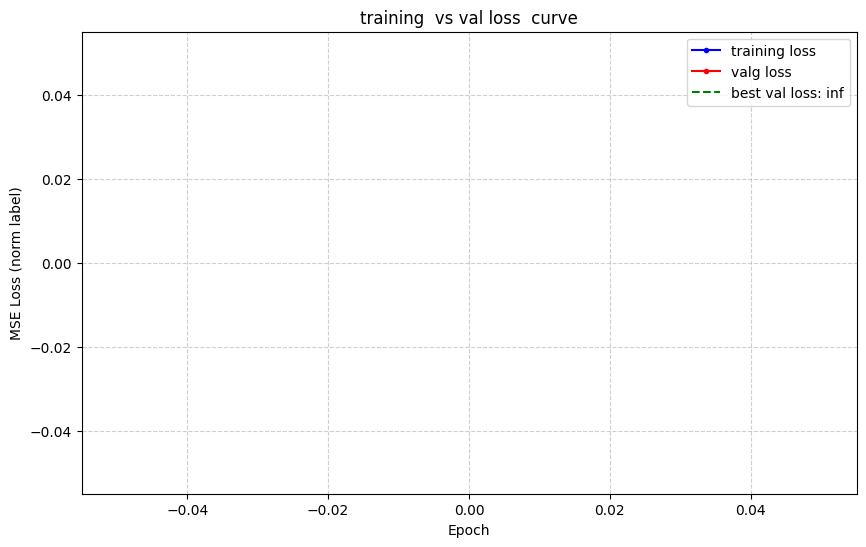

In [ ]:
# ===================== Visualization of training and validation error curves =====================
print("\n=== Visualization of training and validation error curves ===")
plt.figure(figsize=(10, 6))
plt.plot(train_loss_history, label='training loss', color='blue', marker='o', markersize=3)
plt.plot(val_loss_history, label='valg loss', color='red', marker='o', markersize=3)
plt.axhline(y=best_val_loss, color='green', linestyle='--', label=f'best val loss: {best_val_loss:.4f}')
plt.title('training  vs val loss  curve')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss (norm label)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# 4.Model Evaluation and Prediction

## 4.1 Load the best model for final evaluation【code Needed】

In [ ]:
print("=== Load the best model for final evaluation ===")

checkpoint = torch.load(os.path.join(model_path,'best_rul_model.pth'))
model.load_state_dict(checkpoint['model_state_dict'])
print(f"Best model trained at Epoch: {checkpoint['epoch']+1} | Best validation loss: {checkpoint['best_val_loss']:.4f}")

model.eval()
all_preds_norm = [] #Record the normalization results of the predicted values
all_trues_norm = [] #Record the normalization result of the true value
all_trues_raw = []  #Record the results before normalization of the true values

with torch.no_grad():
    for batch in val_loader:
        x_enc, x_mark_enc, x_dec, x_mark_dec, y, y_raw = batch    # 1 code needed
        outputs = model(x_enc, x_mark_enc, x_dec, x_mark_dec)     # 2 code needed

        outputs_clamped = torch.clamp(outputs, min=0.0)
        all_preds_norm.extend(outputs_clamped.cpu().numpy())     # 3 code needed
        all_trues_norm.extend(y.cpu().numpy())                   # 4 code needed
        all_trues_raw.extend(y_raw.cpu().numpy())                # 5 code needed

# Convert to array
all_preds_norm = np.array(all_preds_norm).reshape(-1, 1)
all_trues_norm = np.array(all_trues_norm).reshape(-1, 1)
all_trues_raw = np.array(all_trues_raw).reshape(-1, 1)

# Inverse scaling based on label processing method
all_preds_raw = scaler.inverse_transform(all_preds_norm)      # 6 code needed

all_preds_raw = np.maximum(all_preds_raw, 0)

mse = mean_squared_error(all_trues_raw, all_preds_raw)
mae = mean_absolute_error(all_trues_raw, all_preds_raw)
rmse = math.sqrt(mse)

print(f"=== Optimal model validation set evaluation results ===")
print(f"Validation set MSE (original scale): {mse:.4f}")
print(f"Validation set MAE (original scale): {mae:.4f}")
print(f"Validation set RMSE (original scale): {rmse:.4f}")
print(f"Predicted value range: [{np.min(all_preds_raw):.2f}, {np.max(all_preds_raw):.2f}]")

## 4.2 Visualization of prediction results 【code Needed】

In [ ]:
# =====================  Visualization of prediction results (comparison of 40 random samples)=====================
random_indices = np.random.choice(range(len(all_trues_raw)), size=40, replace=False)
plt.figure(figsize=(12, 6))
plt.plot(all_trues_raw[random_indices], label='True RUL', color='blue', alpha=0.7)
plt.plot(all_preds_raw[random_indices], label='Prediction RUL', color='red', linestyle='--')
plt.title('Best Model RUL Prediction ( random 40 samples )')
plt.xlabel('samples')
plt.ylabel('RUL (hours)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()